In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ugdatalab.models.galaxy_zoo import (
    GalaxyZooData,
    GalaxyZooImages,
    GalaxyZooDataset,
)
from ugdatalab.models.galaxy_zoo.constants import N_LABELS, LABEL_COLUMNS, LABEL_DESCRIPTIVE
from ugdatalab.models.galaxy_zoo.images import _load_image
from ugdatalab.methods.neural_network.cnn import baseline_rmse

import plotters

/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Galaxy Image Classification — Preprocessing

This notebook handles image preprocessing (Tasks 10–13):
1. **Task 10** — Crop and resize images to reduce memory by ~30×
2. **Task 11** — Set up efficient batch loading via PyTorch DataLoader
3. **Task 12** — Split into 80% training / 20% validation and verify label distributions
4. **Task 13** — Establish baseline model (mean prediction) RMSE

In [2]:
CSV_PATH = Path("data/training_classifications.csv")
IMAGE_DIR = Path("data/training_images")

gz = GalaxyZooData(CSV_PATH)
labels_data = np.load("artifacts/galaxy_zoo_labels.npz")
labels = labels_data["labels"]
galaxy_ids = labels_data["galaxy_ids"]

print(f"Galaxies: {len(gz)}")
print(f"Labels shape: {labels.shape}")

Galaxies: 61578
Labels shape: (61578, 37)


## Task 10 — Image Downsizing

The raw SDSS images are ~424×424 pixels, most of which is empty sky. We reduce memory and computation by:

1. **Center-cropping**: removing 25% of the border on each side (keeping the central 50%, which contains the galaxy). This is justified because SDSS cutouts are centered on the target and the outer border is almost always empty sky.
2. **Resampling**: resizing the cropped image to a smaller pixel grid.

The model input size is **96×96**. We cache images at the slightly larger **136×136** ($96 \times \sqrt{2}$, rounded up): this is the smallest size for which an arbitrary rotation of the cached image still fully covers a centered 96×96 inscribed square. Training and evaluation pipelines apply a downstream `CenterCrop(96)` (composed after any rotation augmentation), so the model always sees corner-artifact-free 96×96 input. We use 96 for the model rather than the nominal 64 so that ResNet-18 keeps its standard 7×7 stem; 96 also divides cleanly through four pooling stages (96 → 48 → 24 → 12 → 6).

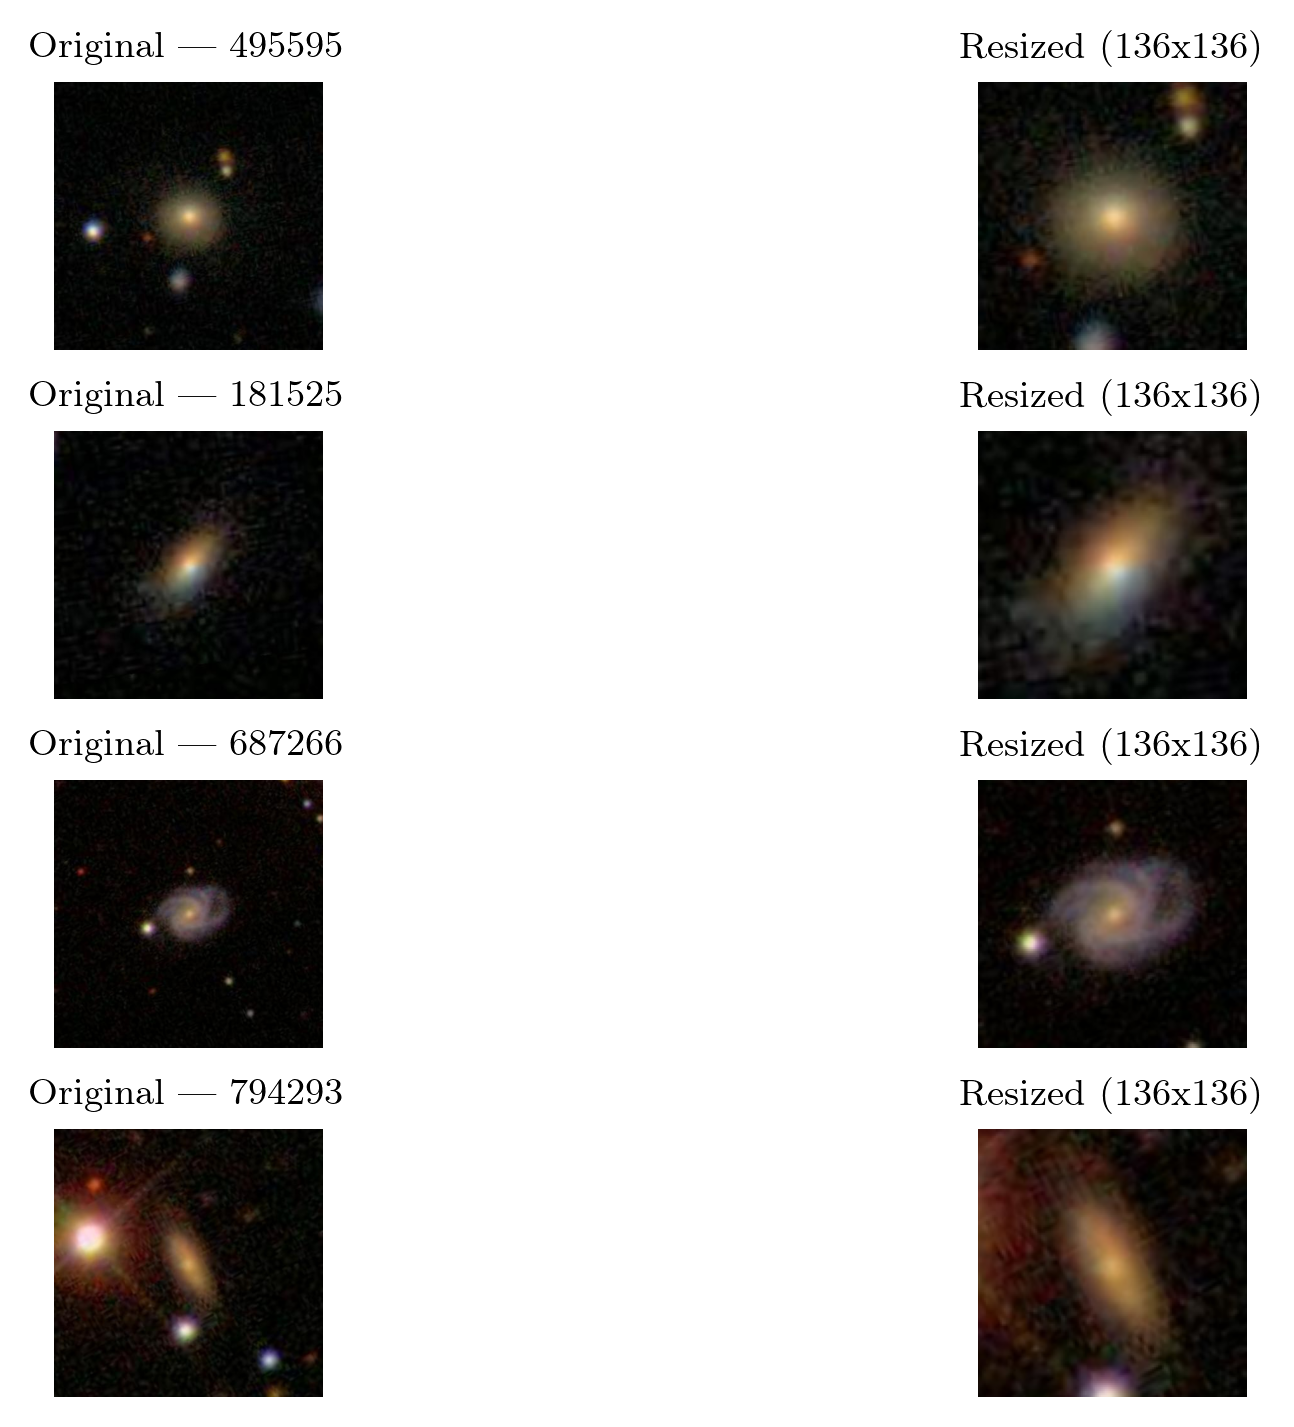

Original: 424x424 = 179,776 pixels
After crop+resize: 136x136 = 18,496 pixels
Reduction factor: 9.7x


In [3]:
CROP_FRACTION = 0.25
# Rotation-safe cache size: ceil(96 * sqrt(2)). Downstream transforms
# rotate then CenterCrop(96), guaranteeing no black-corner artifacts.
CACHE_SIZE = 136

# Show before/after for a few example images
n_compare = 4
rng = np.random.default_rng(42)
compare_idx = rng.choice(len(gz), size=n_compare, replace=False)
compare_ids = galaxy_ids[compare_idx]

images_before = [_load_image(IMAGE_DIR / f"{gid}.jpg") for gid in compare_ids]

from ugdatalab.models.galaxy_zoo.images_pipeline import _crop_center, _resize
images_after = [_resize(_crop_center(img, CROP_FRACTION), CACHE_SIZE) for img in images_before]

axes = plotters.plot_image_comparison(images_before, images_after, compare_ids)
plt.show()

# Report size reduction
h_orig = images_before[0].shape[0]
reduction = (h_orig ** 2) / (CACHE_SIZE ** 2)
print(f"Original: {h_orig}x{h_orig} = {h_orig**2:,} pixels")
print(f"After crop+resize: {CACHE_SIZE}x{CACHE_SIZE} = {CACHE_SIZE**2:,} pixels")
print(f"Reduction factor: {reduction:.1f}x")

### Memory budget (Task 9 follow-through)

The lab manual hints that the full training set will not fit in RAM. We can verify this with a back-of-the-envelope calculation. The raw images are $424 \times 424 \times 3$ pixels stored as 8-bit JPEG on disk, but to feed them to a CNN they must be decoded to floating-point arrays. With 32-bit floats ($4$ bytes per channel), one raw image is

$$424^2 \times 3 \times 4 \,\mathrm{B} \approx 2.16\ \mathrm{MB},$$

so the full $61{,}578$-image training set is

$$61{,}578 \times 2.16\ \mathrm{MB} \approx 133\ \mathrm{GB}.$$

That far exceeds the RAM of any typical workstation, which is exactly the lab manual's point. After the center-crop and resize to $136 \times 136$ done above, one image is only $136^2 \times 3 \times 4 \,\mathrm{B} \approx 222\ \mathrm{kB}$, so the full set drops to

$$61{,}578 \times 222\ \mathrm{kB} \approx 13.7\ \mathrm{GB},$$

which fits in RAM on a 16–32 GB machine and on disk as a single compressed `.npz`. The compression ratio of $\sim 10\times$ in compute and memory is what makes the rest of the lab tractable.

### Preprocess and save all images

We now crop and resize all images and save the result as a compressed numpy archive. This takes a few minutes but only needs to be done once — subsequent notebooks load the preprocessed arrays directly.

In [4]:
_images_npz = Path("artifacts/galaxy_zoo_images.npz")
if _images_npz.exists():
    _cached = np.load(_images_npz)
    print(f"Loaded cached {_images_npz}")
    print(f"  images shape: {_cached['images'].shape}")
    print(f"  memory: {_cached['images'].nbytes / 1e9:.2f} GB")
else:
    gz_images = GalaxyZooImages(
        source=gz,
        image_dir=IMAGE_DIR,
        crop_fraction=CROP_FRACTION,
        target_size=CACHE_SIZE,
    )

    print(f"Preprocessed images shape: {gz_images.images.shape}")
    print(f"Memory: {gz_images.images.nbytes / 1e9:.2f} GB")

    _images_npz.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        _images_npz,
        images=gz_images.images,
        galaxy_ids=galaxy_ids,
    )
    print("Saved artifacts/galaxy_zoo_images.npz")

Loading images: 100%|██████████| 61578/61578 [01:41<00:00, 604.76it/s] 


Preprocessed images shape: (61578, 136, 136, 3)
Memory: 13.67 GB
Saved artifacts/galaxy_zoo_images.npz


## Task 11 — Efficient batch loading

Even after compression the full image array is several GB, so we cannot copy it onto the GPU in one shot. PyTorch's `DataLoader` solves this by streaming mini-batches from a `Dataset` object on CPU while the GPU is busy with the previous batch. We use `ugdatalab.models.galaxy_zoo.GalaxyZooDataset`, which wraps the cached `(N, 136, 136, 3)` array and exposes per-sample `(image_tensor, label_tensor)` pairs in CHW order — exactly what `torch.nn.Conv2d` expects. A `Compose([...])` transform composed of `CenterCrop(96)` (and optionally `RandomRotation360()` during training) is applied per-sample inside `__getitem__`, so augmentation costs CPU time but no extra memory. The dataset is instantiated and handed to a `DataLoader` inside `ugdatalab.methods.neural_network.cnn.train_cnn`, so the notebooks downstream do not have to manage batching themselves.

## Task 12 — Train/Validation Split

We split the data 80/20 into training and validation sets using a random permutation with a fixed seed. After splitting, we compare the normalized label distributions of the two sets to ensure there are no systematic differences — the split should produce statistically indistinguishable distributions for all 37 labels.

Training set: 49262 galaxies (80%)
Validation set: 12316 galaxies (20%)


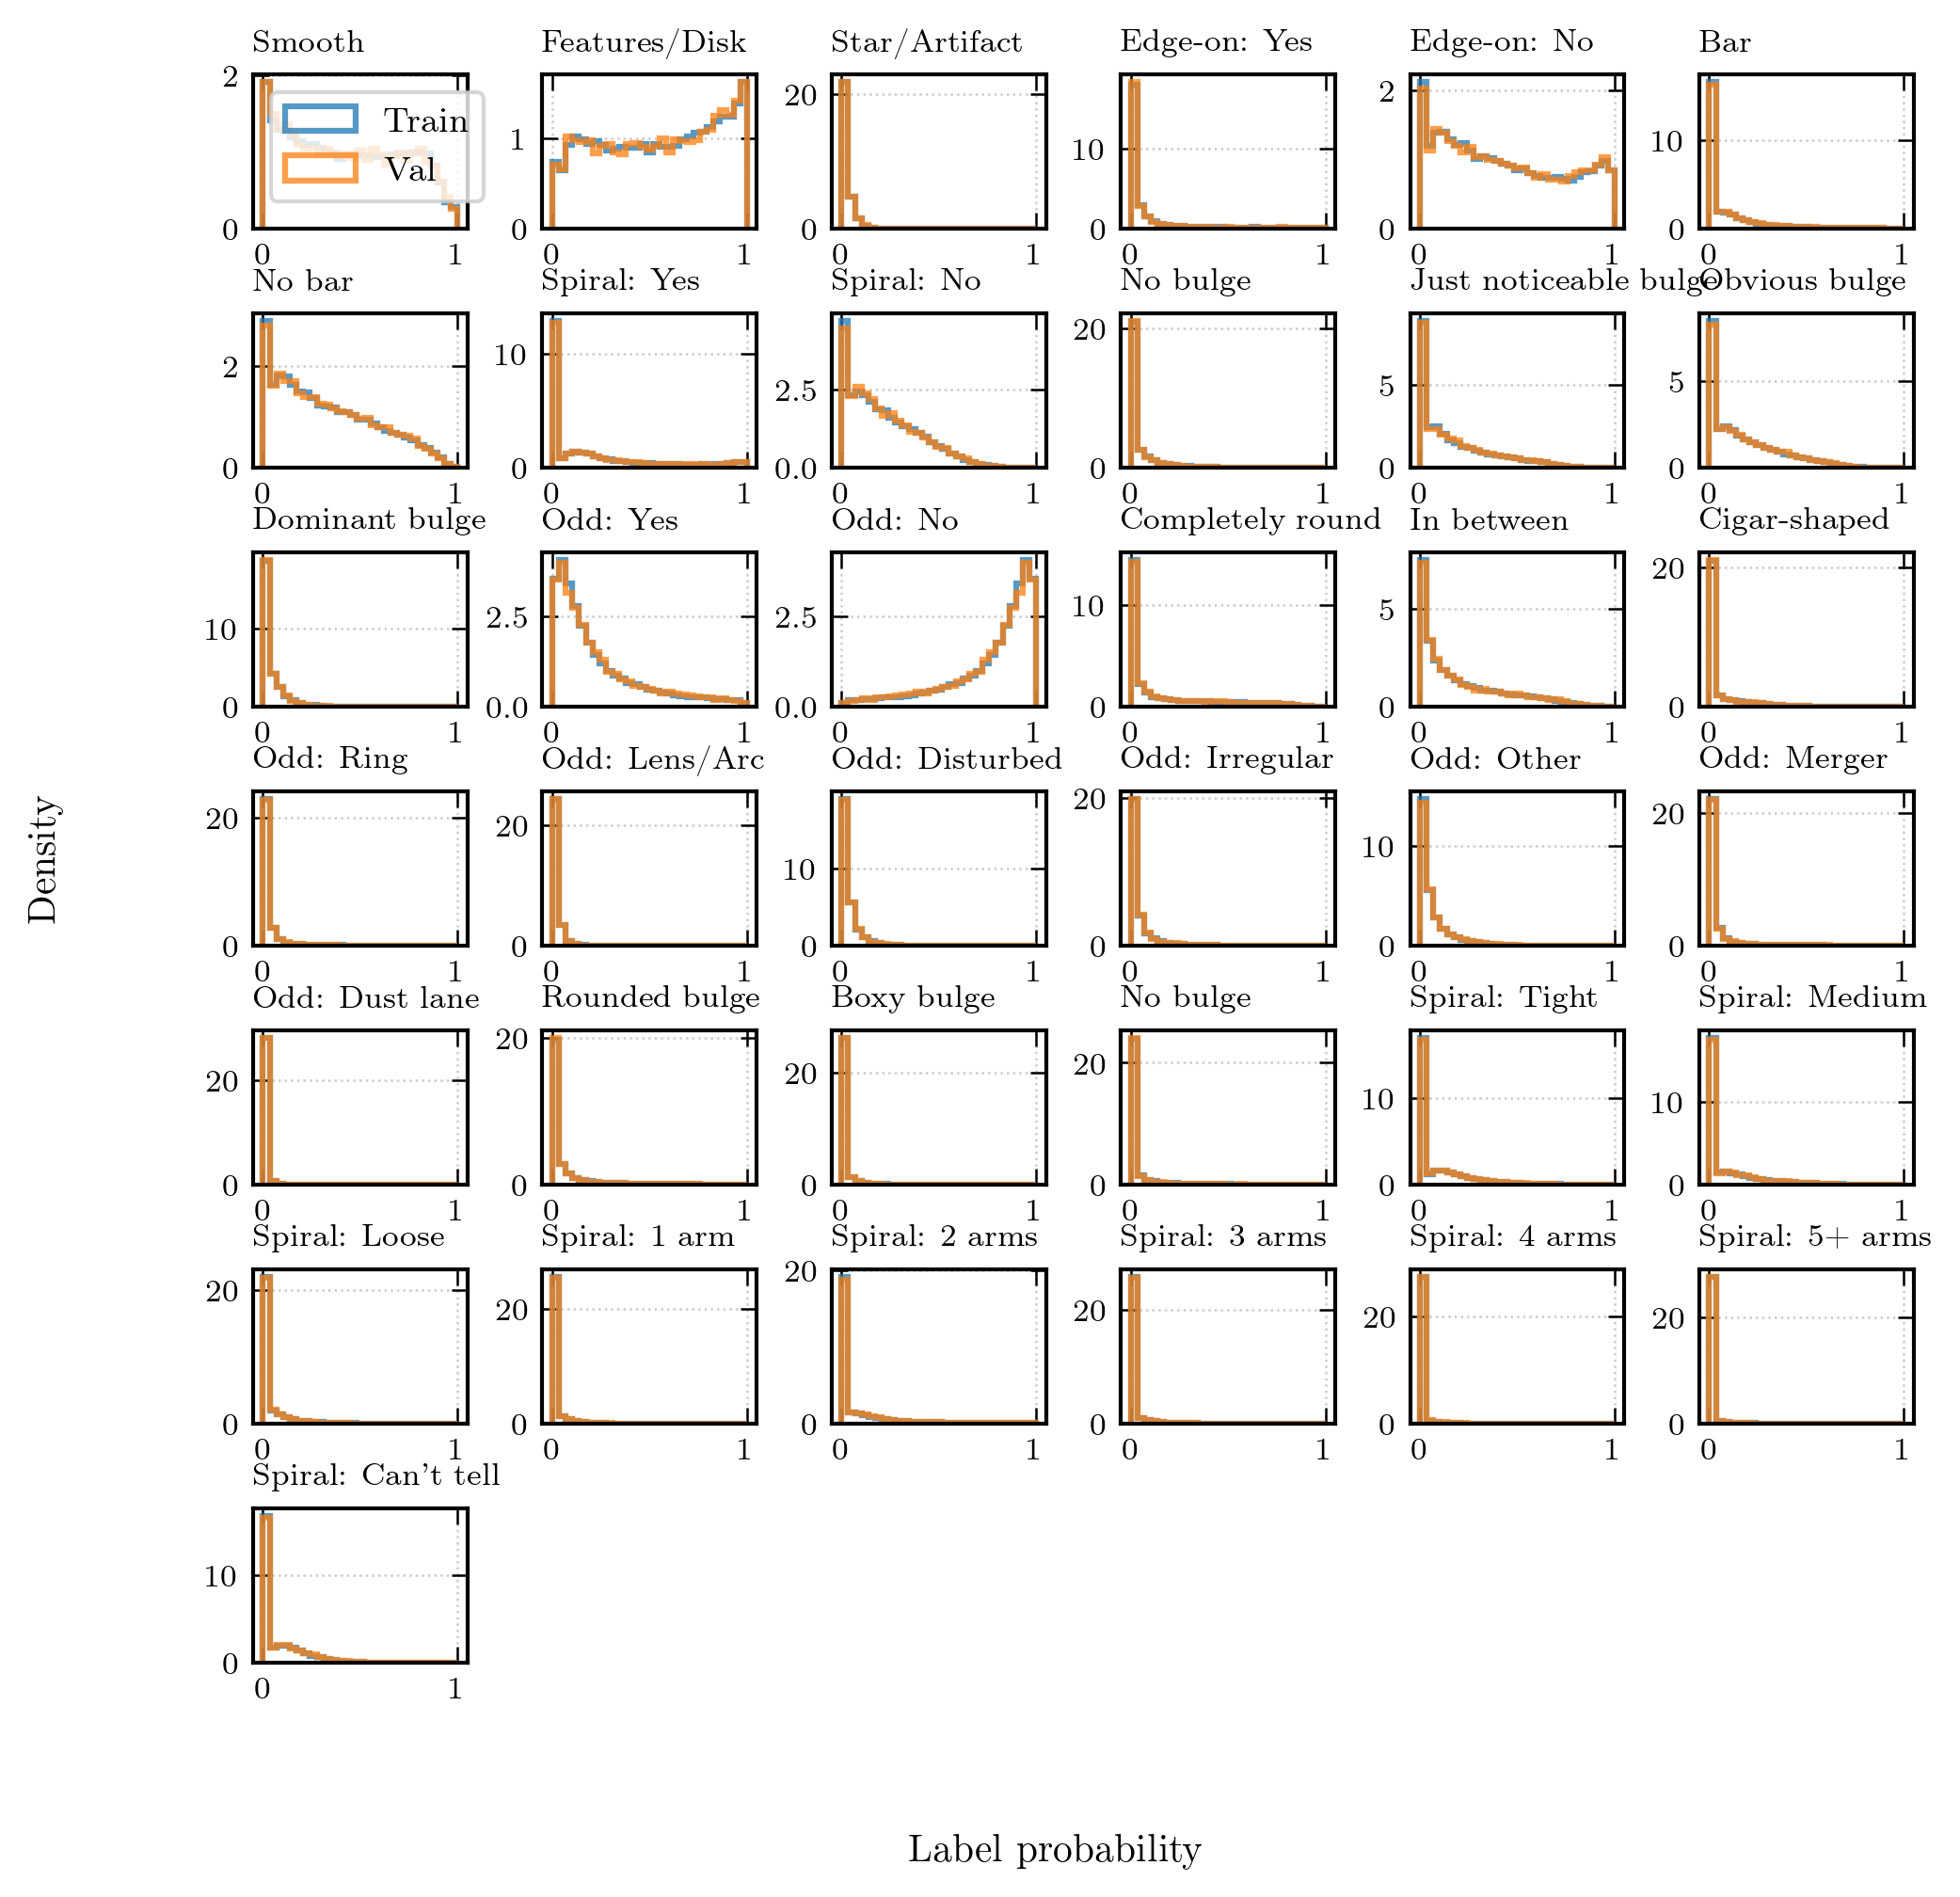

In [5]:
rng = np.random.default_rng(42)
idx = rng.permutation(len(gz))
n_train = int(0.8 * len(gz))
train_idx = np.sort(idx[:n_train])
val_idx = np.sort(idx[n_train:])
train_labels = gz.labels[train_idx]
val_labels = gz.labels[val_idx]

print(f"Training set: {len(train_idx)} galaxies ({len(train_idx)/len(gz)*100:.0f}%)")
print(f"Validation set: {len(val_idx)} galaxies ({len(val_idx)/len(gz)*100:.0f}%)")

# Compare distributions
axes = plotters.plot_split_distributions(
    train_labels, val_labels, LABEL_COLUMNS, LABEL_DESCRIPTIVE,
)
plt.show()

### Interpretation — distribution drift between train and val

Each panel above overlays the normalised histogram of one label for the training (blue) and validation (orange) sets. Because the split is a uniform random permutation, the two distributions should be statistically indistinguishable. Visually they overlap on top of each other for every one of the 37 labels — there is no systematic shift between sets, no missing modes, and the dynamic range of each label is preserved. We therefore use the split as-is and do not resample. (Had we instead split, say, by sky position or by survey plate, we would expect to see drift in colour-correlated labels; the simple permutation avoids that failure mode at the cost of treating each galaxy as independent, which the Galaxy Zoo construction supports.)

## Task 13 — Baseline Model

Before training any neural network, we establish a baseline: predict the training-set mean label for every image. This is the simplest possible model — it ignores the image entirely and always predicts the same label vector. Any useful CNN must outperform this baseline.

The loss function throughout this lab is the **root mean squared error** (RMSE), defined as:

$$L_{\mathrm{RMSE}} = \sqrt{\frac{1}{N_{\mathrm{galaxies}} \cdot N_{\mathrm{labels}}} \sum_i \sum_j (\ell_{\mathrm{true},ij} - \ell_{\mathrm{pred},ij})^2}$$

In [6]:
train_rmse, val_rmse = baseline_rmse(train_labels, val_labels)
print(f"Baseline RMSE (mean prediction):")
print(f"  Training:   {train_rmse:.4f}")
print(f"  Validation: {val_rmse:.4f}")

Baseline RMSE (mean prediction):
  Training:   0.1638
  Validation: 0.1639


### Interpretation — what RMSE = 0.156 means

The bulk RMSE of $\approx 0.156$ sets the bar that any CNN must clear. Breaking it down by label below shows that the baseline error is dominated by the high-variance top-level questions ("smooth vs. features/disk", "edge-on yes/no"): these labels have a broad bimodal distribution in $[0, 1]$ and therefore a large variance around their mean, which is essentially what the per-label baseline RMSE measures ($\sigma_\ell$ since the prediction is the mean). The easiest labels are the rare-event children deep in the GZ2 decision tree (e.g. "odd: lens/arc"): almost every galaxy has a vote fraction near 0 for these, so always predicting the mean is already very close to the truth. A successful CNN must drive the *hard* labels' RMSE down without inflating error on the easy ones — the per-label scatter plot in `06-evaluation.ipynb` is exactly the diagnostic for that.

In [7]:
import pandas as pd
from ugdatalab.models.galaxy_zoo.constants import LABEL_DESCRIPTIVE

# Per-label baseline: predict the training-set mean for every galaxy.
mean_pred = train_labels.mean(axis=0)
per_label_train = np.sqrt(((train_labels - mean_pred) ** 2).mean(axis=0))
per_label_val = np.sqrt(((val_labels - mean_pred) ** 2).mean(axis=0))

baseline_table = pd.DataFrame({
    "label": [LABEL_DESCRIPTIVE[c] for c in LABEL_COLUMNS],
    "mean": mean_pred,
    "train_rmse": per_label_train,
    "val_rmse": per_label_val,
}).sort_values("val_rmse", ascending=False).reset_index(drop=True)

print("Top-5 hardest labels for the mean-prediction baseline:")
display(baseline_table.head(5))
print("\nTop-5 easiest labels for the mean-prediction baseline:")
display(baseline_table.tail(5).iloc[::-1])


Top-5 hardest labels for the mean-prediction baseline:


,label,mean,train_rmse,val_rmse
0,Edge-on: No,0.434754,0.301789,0.302159
1,Features/Disk,0.541827,0.296355,0.296708
2,Spiral: Yes,0.214690,0.285238,0.286652
3,Smooth,0.432946,0.283389,0.284023
4,No bar,0.332744,0.247765,0.247330



Top-5 easiest labels for the mean-prediction baseline:


,label,mean,train_rmse,val_rmse
36,Odd: Dust lane,0.003798,0.024008,0.025969
35,Odd: Lens/Arc,0.013471,0.027463,0.027324
34,Spiral: 5+ arms,0.007059,0.037320,0.037119
33,Star/Artifact,0.025232,0.038100,0.037429
32,Boxy bulge,0.010665,0.038173,0.038510


### Save split indices and preprocessed data

In [8]:
_split_npz = Path("artifacts/split_indices.npz")
if _split_npz.exists():
    print(f"Skipping save: {_split_npz} already exists")
else:
    _split_npz.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        _split_npz,
        train_idx=train_idx,
        val_idx=val_idx,
        baseline_train_rmse=train_rmse,
        baseline_val_rmse=val_rmse,
    )
    print("Saved artifacts/split_indices.npz")
    print(f"  train_idx: {train_idx.shape}")
    print(f"  val_idx: {val_idx.shape}")

Saved artifacts/split_indices.npz
  train_idx: (49262,)
  val_idx: (12316,)
